# 03 — Inference & Explainability Demo

A short, presentation-friendly walkthrough of the trained model in action:

1. Load the trained checkpoint.
2. Classify a single beat and show the probability distribution.
3. Explain the decision with **Grad-CAM** — which samples did the model rely on?

> Train a model first with `python -m src.train`. If no checkpoint exists this notebook falls back to an untrained model so the code still runs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
from pathlib import Path

from src.utils import load_config, get_device, AAMI_CLASSES
from src.model import build_model
from src.evaluate import load_checkpoint_model
from src.predict import predict_beat
from src.gradcam import GradCAM1D, plot_gradcam
from src.visualization import plot_prediction

config = load_config('../config.yaml')
config.data['processed_dir'] = '../' + config.data['processed_dir']
device = get_device()
L = 2 * config.data['beat_window']

ckpt = Path('../models/best_model.pt')
if ckpt.exists():
    model = load_checkpoint_model(ckpt, config, device)
    print('Loaded trained model.')
else:
    model = build_model(config.model, input_length=L).to(device).eval()
    print('No checkpoint - using an untrained model for demo purposes.')

Loaded trained model.


## Pick a beat

We try to load a real beat from the processed cache; otherwise we synthesise one.

In [2]:
cache = Path(config.data['processed_dir']) / 'beats.npz'
if cache.exists():
    data = np.load(cache, allow_pickle=False)
    signals, labels = data['signals'], data['labels']
    # Grab one ventricular beat if present, else the first beat.
    v_idx = np.where(labels == AAMI_CLASSES.index('V'))[0]
    i = int(v_idx[0]) if len(v_idx) else 0
    beat = signals[i]; true_label = AAMI_CLASSES[labels[i]]
else:
    t = np.linspace(0, 1, L)
    beat = np.exp(-0.5 * ((t - 0.5) / 0.04) ** 2).astype(np.float32)
    beat = (beat - beat.mean()) / (beat.std() + 1e-8)
    true_label = 'unknown (synthetic)'
print('True label:', true_label)

True label: V


V (Ventricular) | confidence 0.947 | [N:0.023, S:0.002, V:0.947, F:0.017, Q:0.011]


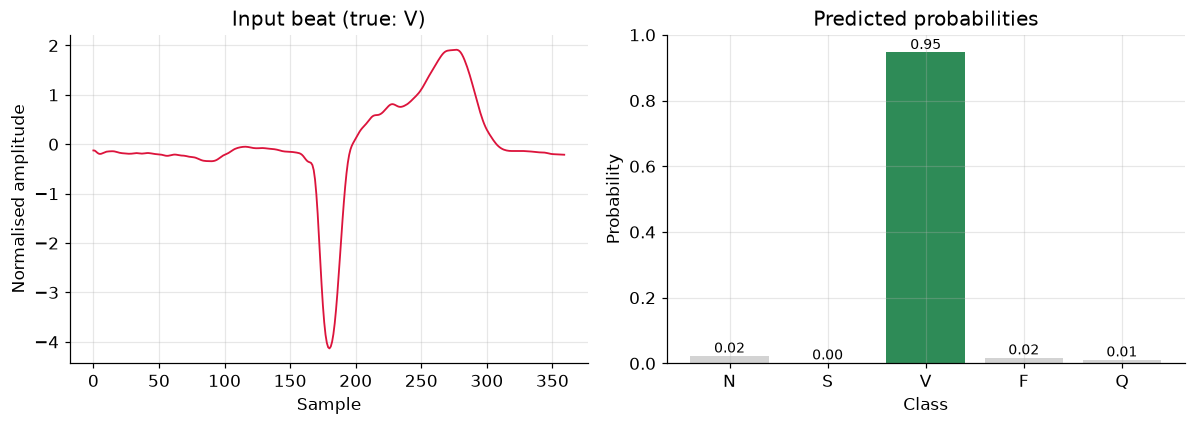

In [3]:
pred = predict_beat(beat, model, device, already_normalized=True)
print(pred)
probs = np.array([pred.probabilities[c] for c in AAMI_CLASSES])
plot_prediction(beat, probs, true_label=true_label);

## Grad-CAM explanation

The saliency overlay shows which parts of the beat drove the prediction. On a well-trained model the **QRS complex** should light up.

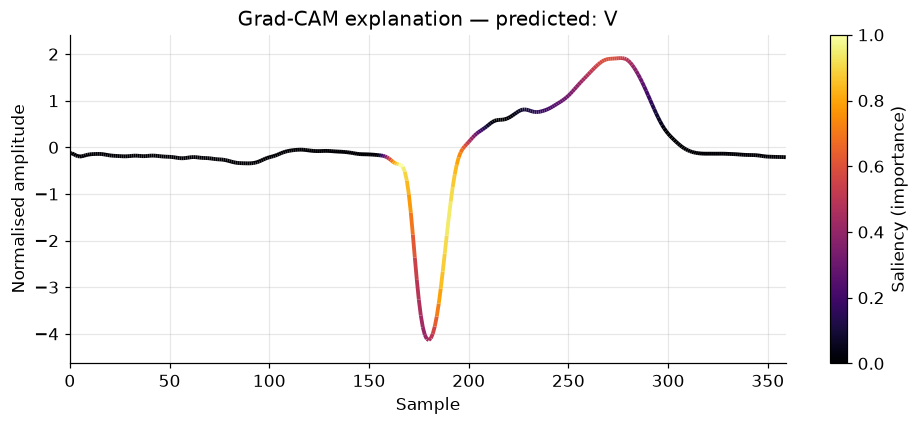

In [4]:
cam = GradCAM1D(model)
beat_tensor = torch.from_numpy(beat).float().view(1, 1, -1).to(device)
saliency = cam(beat_tensor)
plot_gradcam(beat, saliency, pred.predicted_class);